# 01 — Ghost Center Detection
**UIDAI Aadhaar Fraud Intelligence System — Thane District**

---

### Objective
A legitimate Aadhaar center operates all 3 streams — Biometric, Demographic, and Enrollment — in sync.
A **ghost center** is one where one stream goes completely silent while others remain active.
This notebook detects such centers using a custom **Sync Gap Index (SGI)** score.

### Pipeline
```
master_aadhaar_thane.csv
        ↓
Feature Engineering (SGI + 4 supporting metrics)
        ↓
Statistical Threshold Discovery (Tier 1 / Tier 2)
        ↓
Ghost Center Detection Engine
        ↓
K-Means Operational Segmentation (4 archetypes)
        ↓
Final Audit Target List → reports/
```

## Cell 1 — Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ── Plot config ──────────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# ── Paths (relative to notebooks/) ──────────────────────────
DATA_PATH    = '../data/processed/master_aadhaar_thane.csv'
REPORTS_DIR  = '../reports'
OUTPUTS_DIR  = '../outputs'
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# ── Load ─────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
df['month'] = pd.to_datetime(df['month']).dt.to_period('M')

print(f"Rows     : {len(df)}")
print(f"Columns  : {df.columns.tolist()}")
print(f"Pincodes : {df['pincode'].nunique()}")
print(f"Months   : {sorted(df['month'].astype(str).unique())}")
df.head()

Rows     : 982
Columns  : ['pincode', 'month', 'bio_child', 'bio_adult', 'bio_total', 'demo_child', 'demo_adult', 'demo_total', 'enrol_infant', 'enrol_child', 'enrol_adult', 'enrol_total']
Pincodes : 96
Months   : ['2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01']


,pincode,month,bio_child,bio_adult,bio_total,demo_child,demo_adult,demo_total,enrol_infant,enrol_child,enrol_adult,enrol_total
0,400601,2025-03,0.0,0.0,0.0,99.0,1058.0,1157.0,0.0,0.0,0.0,0.0
1,400601,2025-04,393.0,831.0,1224.0,104.0,783.0,887.0,0.0,0.0,0.0,0.0
2,400601,2025-05,575.0,1122.0,1697.0,0.0,0.0,0.0,80.0,30.0,14.0,124.0
3,400601,2025-06,165.0,670.0,835.0,0.0,0.0,0.0,45.0,31.0,1.0,77.0
4,400601,2025-07,407.0,912.0,1319.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Cell 2 — Feature Engineering

We engineer **5 behavioral indicators** from the raw transaction data.

| Metric | Formula | What it detects |
|---|---|---|
| `SGI_Score` | `abs(bio_total - demo_total) / (bio_total + demo_total + 1)` | Stream desynchronization → Ghost Centers |
| `total_txn` | `bio_total + demo_total + enrol_total` | Overall center activity |
| `Identity_Churn` | `(demo_adult + bio_adult) / (total_txn + 1)` | Adult identity instability |
| `Bio_Distress` | `bio_adult / (demo_adult + 1)` | Biometric-only activity without paired demo updates |
| `Enrol_Saturation` | `enrol_total / (total_txn + 1)` | Proportion of activity that is new enrollment |

In [2]:
# ── Total activity ────────────────────────────────────────────
df['total_txn'] = df['bio_total'] + df['demo_total'] + df['enrol_total']

# ── SGI Score (core ghost detection metric) ───────────────────
# Score → 1.0 means one stream is completely dead
# Score → 0.0 means both streams are perfectly balanced
df['SGI_Score'] = (
    abs(df['bio_total'] - df['demo_total']) /
    (df['bio_total'] + df['demo_total'] + 1)
)

# ── Supporting behavioral metrics ────────────────────────────
df['Identity_Churn']  = (df['demo_adult'] + df['bio_adult']) / (df['total_txn'] + 1)
df['Bio_Distress']    = df['bio_adult'] / (df['demo_adult'] + 1)
df['Enrol_Saturation']= df['enrol_total'] / (df['total_txn'] + 1)

print("Features engineered successfully.")
print(f"\nSGI Score range  : {df['SGI_Score'].min():.4f} → {df['SGI_Score'].max():.4f}")
print(f"Mean SGI Score   : {df['SGI_Score'].mean():.4f}")
print(f"\nRows with SGI > 0.8 (potential ghosts): {(df['SGI_Score'] > 0.8).sum()}")

df[['pincode', 'month', 'total_txn', 'SGI_Score', 'Identity_Churn', 'Bio_Distress', 'Enrol_Saturation']].head(10)

Features engineered successfully.

SGI Score range  : 0.0000 → 0.9999
Mean SGI Score   : 0.6065

Rows with SGI > 0.8 (potential ghosts): 439


,pincode,month,total_txn,SGI_Score,Identity_Churn,Bio_Distress,Enrol_Saturation
0,400601,2025-03,1157.0,0.999136,0.913644,0.000000,0.000000
1,400601,2025-04,2111.0,0.159564,0.764205,1.059949,0.000000
2,400601,2025-05,1821.0,0.999411,0.615807,1122.000000,0.068057
3,400601,2025-06,912.0,0.998804,0.733844,670.000000,0.084337
4,400601,2025-07,1319.0,0.999242,0.690909,912.000000,0.000000
5,400601,2025-08,941.0,0.998938,0.754777,711.000000,0.000000
6,400601,2025-09,2505.0,0.433986,0.630886,1.623549,0.063049
7,400601,2025-10,1928.0,0.432226,0.649041,1.729847,0.047693
8,400601,2025-11,4355.0,0.320298,0.683655,1.250000,0.043159
9,400601,2025-12,3926.0,0.374643,0.640693,1.263489,0.019862


## Cell 3 — Statistical Threshold Discovery

We use **data-driven percentile analysis** to define operational tiers.
This avoids arbitrary cutoffs — every threshold is backed by the distribution.

  OPERATIONAL VOLUME BASELINES
  25th percentile :    148 txns/month
  50th percentile :    527 txns/month
  75th percentile :   1501 txns/month
  90th percentile :   3218 txns/month
  95th percentile :   5139 txns/month

  Tier 1 Watchlist (> 200 txns) : 70.6% of center-months
  Tier 2 Critical  (> 500 txns) : 51.2% of center-months


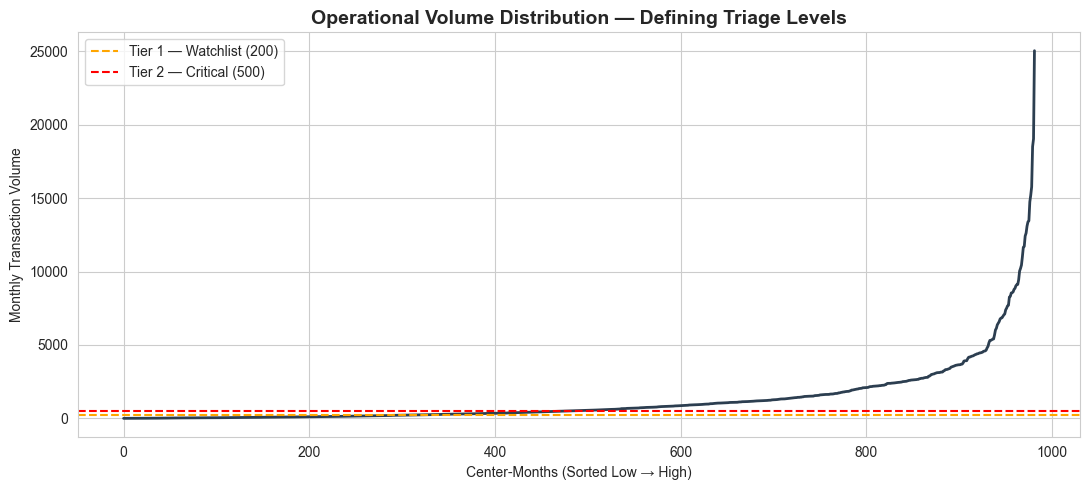

Saved → outputs/volume_distribution.png


In [3]:
# ── Volume distribution ───────────────────────────────────────
quantiles = df['total_txn'].quantile([0.25, 0.50, 0.75, 0.90, 0.95])

print("=" * 50)
print("  OPERATIONAL VOLUME BASELINES")
print("=" * 50)
for q, v in quantiles.items():
    print(f"  {int(q*100):>2d}th percentile : {int(v):>6} txns/month")

# ── Define tiers ──────────────────────────────────────────────
TIER_1 = 200   # Watchlist  — automated alert
TIER_2 = 500   # Critical   — physical audit required

t1_pct = (df['total_txn'] > TIER_1).sum() / len(df) * 100
t2_pct = (df['total_txn'] > TIER_2).sum() / len(df) * 100

print(f"\n  Tier 1 Watchlist (> {TIER_1} txns) : {t1_pct:.1f}% of center-months")
print(f"  Tier 2 Critical  (> {TIER_2} txns) : {t2_pct:.1f}% of center-months")

# ── Elbow curve ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(np.sort(df['total_txn']), color='#2c3e50', linewidth=2)
ax.axhline(TIER_1, color='orange', linestyle='--', linewidth=1.5, label=f'Tier 1 — Watchlist ({TIER_1})')
ax.axhline(TIER_2, color='red',    linestyle='--', linewidth=1.5, label=f'Tier 2 — Critical ({TIER_2})')
ax.set_title('Operational Volume Distribution — Defining Triage Levels', fontsize=14, fontweight='bold')
ax.set_xlabel('Center-Months (Sorted Low → High)')
ax.set_ylabel('Monthly Transaction Volume')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/volume_distribution.png', dpi=150)
plt.show()
print("Saved → outputs/volume_distribution.png")

## Cell 4 — Ghost Center Detection Engine

**Detection Logic:**
- `SGI_Score > 0.8` → one stream is **9x larger** than the other (near-impossible for a legitimate center)
- Combined with volume tier → 2-level alert system

| Tier | Condition | Action |
|---|---|---|
| Critical (Tier 2) | SGI > 0.8 AND total_txn > 500 | Immediate physical audit |
| Watchlist (Tier 1) | SGI > 0.8 AND 200 ≤ total_txn ≤ 500 | Automated digital alert |

  ANOMALY DETECTION REPORT
  Critical Ghost Centers (Tier 2) :  179 instances
  Watchlist Ghost Centers (Tier 1) :  107 instances
  Total Ghost Instances            :  286

Top 10 Critical Ghosts:


,month,pincode,bio_total,demo_total,SGI_Score,total_txn
767,2025-08,421302,6767.0,0.0,0.999852,6767.0
803,2025-04,421306,4576.0,0.0,0.999782,4905.0
104,2025-08,400612,4800.0,0.0,0.999792,4800.0
762,2025-03,421302,0.0,4649.0,0.999785,4649.0
267,2025-03,401107,0.0,4154.0,0.999759,4154.0
709,2025-05,421201,3898.0,0.0,0.999744,3898.0
247,2025-05,401105,3689.0,0.0,0.999729,3689.0
804,2025-05,421306,3548.0,0.0,0.999718,3548.0
45,2025-04,400605,3154.0,0.0,0.999683,3154.0
901,2025-07,421503,2065.0,0.0,0.999516,2775.0


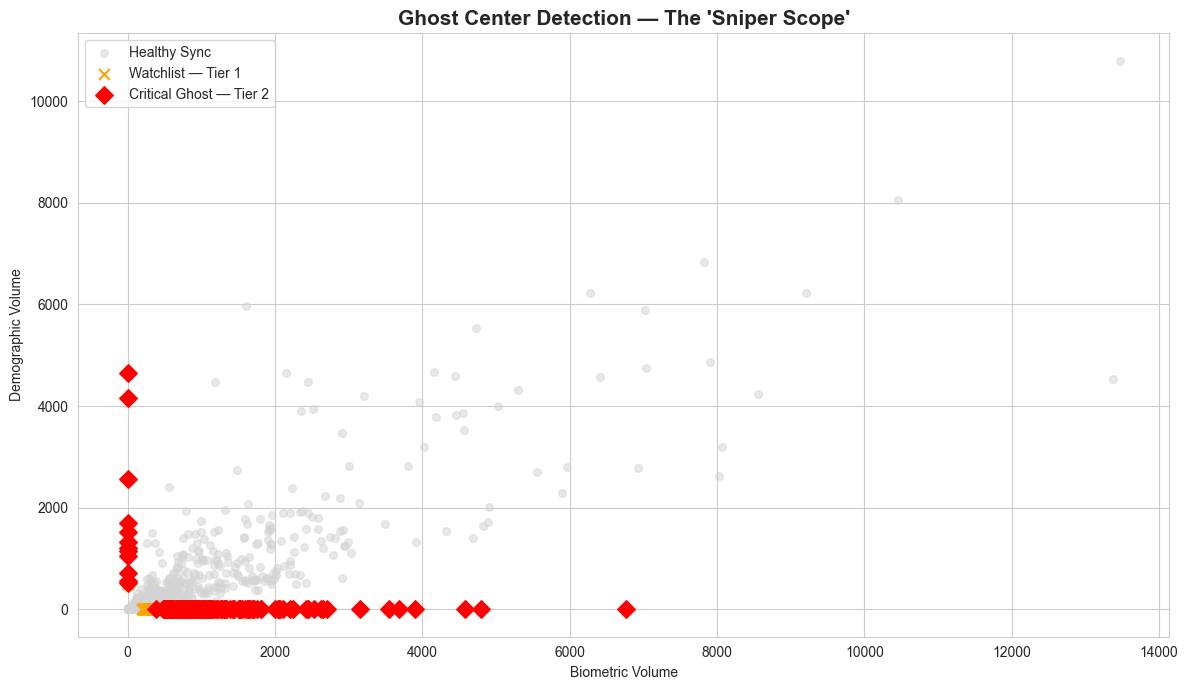

Saved → outputs/sniper_scope.png


In [4]:
GHOST_THRESHOLD = 0.8

# ── Tier 2: Critical ghosts ───────────────────────────────────
critical = df[
    (df['SGI_Score'] > GHOST_THRESHOLD) &
    (df['total_txn'] > TIER_2)
].sort_values('total_txn', ascending=False).copy()

# ── Tier 1: Watchlist ghosts ──────────────────────────────────
watchlist = df[
    (df['SGI_Score'] > GHOST_THRESHOLD) &
    (df['total_txn'] >= TIER_1) &
    (df['total_txn'] <= TIER_2)
].sort_values('total_txn', ascending=False).copy()

print("=" * 55)
print("  ANOMALY DETECTION REPORT")
print("=" * 55)
print(f"  Critical Ghost Centers (Tier 2) : {len(critical):>4} instances")
print(f"  Watchlist Ghost Centers (Tier 1) : {len(watchlist):>4} instances")
print(f"  Total Ghost Instances            : {len(critical)+len(watchlist):>4}")

print("\nTop 10 Critical Ghosts:")
display(critical[['month','pincode','bio_total','demo_total','SGI_Score','total_txn']].head(10))

# ── Sniper Scope Plot ─────────────────────────────────────────
healthy = df[df['SGI_Score'] <= GHOST_THRESHOLD]

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(healthy['bio_total'],   healthy['demo_total'],
           c='lightgrey', alpha=0.5, s=30, label='Healthy Sync')
ax.scatter(watchlist['bio_total'], watchlist['demo_total'],
           c='orange', marker='x', s=60, label='Watchlist — Tier 1')
ax.scatter(critical['bio_total'],  critical['demo_total'],
           c='red', marker='D', s=80, label='Critical Ghost — Tier 2')
ax.set_title("Ghost Center Detection — The 'Sniper Scope'", fontsize=15, fontweight='bold')
ax.set_xlabel('Biometric Volume')
ax.set_ylabel('Demographic Volume')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/sniper_scope.png', dpi=150)
plt.show()
print("Saved → outputs/sniper_scope.png")

## Cell 5 — Operational Segmentation (K-Means)

We cluster all active pincodes into **4 operational archetypes** using K-Means.
Log-transforms are applied to skewed features before clustering to prevent
high-magnitude features from dominating the distance metric.

In [5]:
# ── Aggregate to pincode level ────────────────────────────────
pin_profile = (
    df.groupby('pincode')[['SGI_Score','Identity_Churn','Bio_Distress','Enrol_Saturation','total_txn']]
      .mean()
      .reset_index()
)

# Filter: only Tier 1+ centers (exclude noise)
pin_profile = pin_profile[pin_profile['total_txn'] > TIER_1].copy()
print(f"Pincodes in clustering scope: {len(pin_profile)}")

# ── Log-transform skewed features ────────────────────────────
pin_profile['Bio_Distress_Log'] = np.log1p(pin_profile['Bio_Distress'])
pin_profile['Volume_Log']       = np.log1p(pin_profile['total_txn'])

# ── Scale & cluster ───────────────────────────────────────────
FEATURES = ['SGI_Score','Identity_Churn','Bio_Distress_Log','Enrol_Saturation','Volume_Log']
X_scaled = StandardScaler().fit_transform(pin_profile[FEATURES])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
pin_profile['Cluster'] = kmeans.fit_predict(X_scaled)

# ── Cluster summary ───────────────────────────────────────────
summary_cols = ['SGI_Score','Identity_Churn','Bio_Distress','Enrol_Saturation','total_txn']
cluster_summary = pin_profile.groupby('Cluster')[summary_cols].mean().round(3)

print("\n── Cluster Centroids ──")
display(cluster_summary)

Pincodes in clustering scope: 70

── Cluster Centroids ──


,SGI_Score,Identity_Churn,Bio_Distress,Enrol_Saturation,total_txn
Cluster,,,,,
0,0.624,0.703,107.173,0.027,596.812
1,0.417,0.699,323.735,0.061,6217.295
2,0.636,0.919,188.518,0.019,685.166
3,0.620,0.687,346.996,0.033,1883.697


## Cell 6 — Cluster Labeling & Visualization

Category distribution:
Category
HIGH-RISK: Desynchronized Hub    261
Tier 3: Low Activity             238
PRIORITY: Migration Hotspot      201
Review: Silent Node              194
STABLE: Mega-Hub                  88
Name: count, dtype: int64


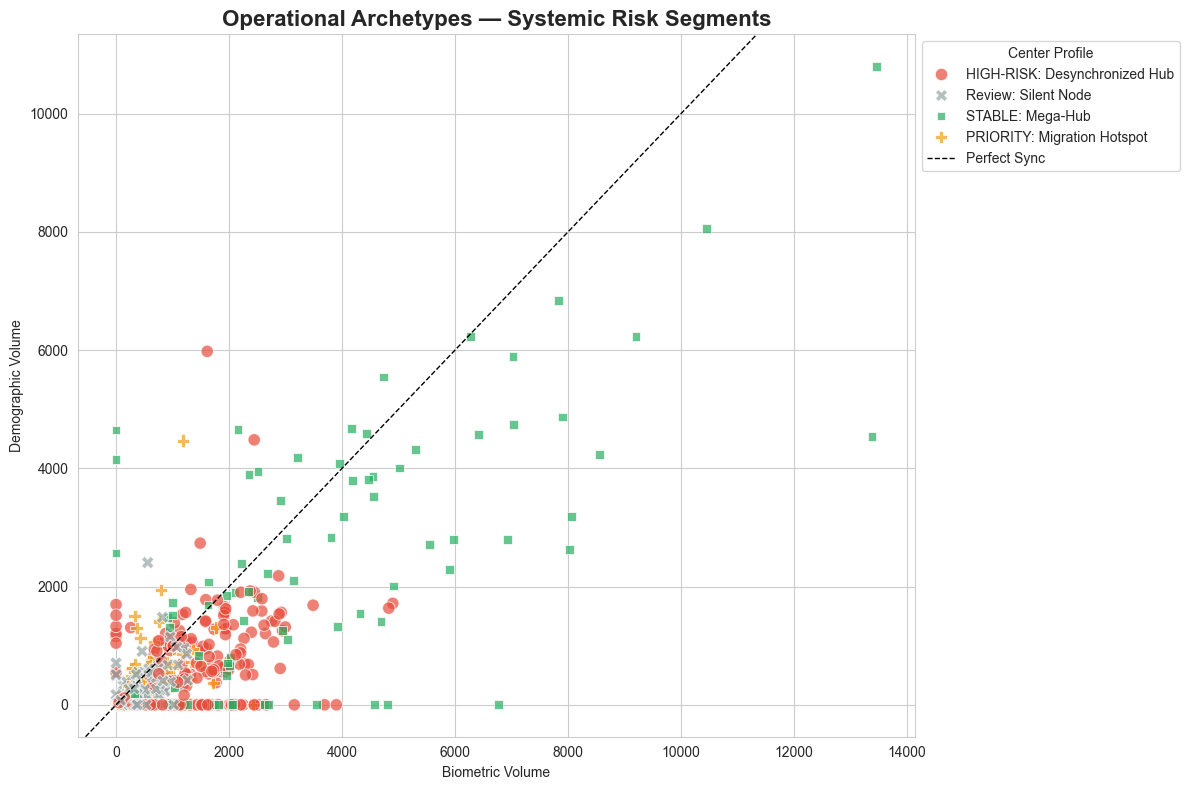

Saved → outputs/risk_segments.png


In [6]:
# ── Label clusters based on centroid characteristics ─────────
# Inspect cluster_summary above to assign labels
CLUSTER_LABELS = {
    0: 'Review: Silent Node',
    1: 'STABLE: Mega-Hub',
    2: 'PRIORITY: Migration Hotspot',
    3: 'HIGH-RISK: Desynchronized Hub'
}

pin_profile['Category'] = pin_profile['Cluster'].map(CLUSTER_LABELS)

# Merge labels back to main df
final_df = df.merge(
    pin_profile[['pincode','Cluster','Category']],
    on='pincode', how='left'
)
final_df['Category'] = final_df['Category'].fillna('Tier 3: Low Activity')

print("Category distribution:")
print(final_df['Category'].value_counts())

# ── Systemic Risk Scatter ─────────────────────────────────────
PALETTE = {
    'HIGH-RISK: Desynchronized Hub' : '#e74c3c',
    'PRIORITY: Migration Hotspot'   : '#f39c12',
    'STABLE: Mega-Hub'              : '#27ae60',
    'Review: Silent Node'           : '#95a5a6',
    'Tier 3: Low Activity'          : '#dfe6e9'
}

plot_data = final_df[final_df['Category'] != 'Tier 3: Low Activity']

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=plot_data, x='bio_total', y='demo_total',
    hue='Category', style='Category',
    palette=PALETTE, s=80, alpha=0.7, ax=ax
)
ax.axline((0,0), slope=1, color='black', linestyle='--', linewidth=1, label='Perfect Sync')
ax.set_title('Operational Archetypes — Systemic Risk Segments', fontsize=16, fontweight='bold')
ax.set_xlabel('Biometric Volume')
ax.set_ylabel('Demographic Volume')
ax.legend(title='Center Profile', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/risk_segments.png', dpi=150)
plt.show()
print("Saved → outputs/risk_segments.png")

## Cell 7 — Final Audit Target List

A center is a **confirmed fraud target** only if it triggered the Critical Ghost
alert in **2 or more separate months** — filtering out one-off data glitches.

In [7]:
# ── Count ghost months per pincode ────────────────────────────
ghost_counts = (
    critical['pincode']
    .value_counts()
    .reset_index()
)
ghost_counts.columns = ['pincode', 'ghost_months']

# ── Filter: repeat offenders only (≥ 2 months) ───────────────
audit_targets = ghost_counts[ghost_counts['ghost_months'] >= 2].copy()

# ── Add cluster context ───────────────────────────────────────
audit_targets = audit_targets.merge(
    pin_profile[['pincode','Category']],
    on='pincode', how='left'
)

audit_targets = audit_targets.sort_values('ghost_months', ascending=False).reset_index(drop=True)

print("=" * 55)
print("  FINAL AUDIT TARGETS — REPEAT OFFENDERS")
print("=" * 55)
print(f"  Total confirmed targets : {len(audit_targets)}")
print(f"  Max ghost months        : {audit_targets['ghost_months'].max()}")
print()
display(audit_targets)

# ── Export ────────────────────────────────────────────────────
audit_targets.to_csv(f'{REPORTS_DIR}/final_audit_targets.csv', index=False)
critical.to_csv(f'{REPORTS_DIR}/ghost_center_list.csv', index=False)

print("\nSaved → reports/final_audit_targets.csv")
print("Saved → reports/ghost_center_list.csv")

  FINAL AUDIT TARGETS — REPEAT OFFENDERS
  Total confirmed targets : 42
  Max ghost months        : 6



,pincode,ghost_months,Category
0,421201,6,HIGH-RISK: Desynchronized Hub
1,401105,6,HIGH-RISK: Desynchronized Hub
2,400709,6,HIGH-RISK: Desynchronized Hub
3,421401,6,HIGH-RISK: Desynchronized Hub
4,421004,5,HIGH-RISK: Desynchronized Hub
5,421305,5,HIGH-RISK: Desynchronized Hub
6,400601,5,HIGH-RISK: Desynchronized Hub
7,400604,5,HIGH-RISK: Desynchronized Hub
8,421202,5,HIGH-RISK: Desynchronized Hub
9,401101,5,HIGH-RISK: Desynchronized Hub



Saved → reports/final_audit_targets.csv
Saved → reports/ghost_center_list.csv
